## Finetune with LoRA

This notebook will finetune a pretrained instruct model with some preference data with the goal of obtaining a new model that resembles the prefer response type. This will use synthetic data that was generated by `generate_training_data.ipnyb`

In [ ]:
import time
import torch
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import json
from huggingface_hub import login
from transformers import AutoTokenizer, AutoModelForCausalLM, DataCollatorWithPadding
import random
import torch.nn as nn
import math
from torch.nn.utils.rnn import pad_sequence
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

### Load data

In [2]:
PREFERENCE_DATA = 'questions_preference.json'

with open(PREFERENCE_DATA, 'r') as f:
    data = json.load(f)

In [3]:
data[0]

{'question': 'What are the signs of a toxic partner?',
 'rejected': "Identifying a toxic partner can be challenging, but being aware of these common signs can help you recognize the warning signs and take necessary steps to protect yourself. Here are some common indicators of a toxic partner:\n\n1. **Controlling behavior**: They try to control what you wear, who you hang out with, or what you do.\n2. **Emotional manipulation**: They use guilt, anger, or self-pity to make you feel bad about yourself or your choices.\n3. **Verbal abuse**: They regularly use put-downs, insults, or name-calling to belittle you.\n4. **Gaslighting**: They deny previous agreements or conversations, making you question your own memory or sanity.\n5. **Isolation**: They isolate you from friends and family, making it difficult for you to have a support network.\n6. **Possessiveness**: They become overly possessive, jealous, or insecure when you spend time with others.\n7. **Disrespect**: They consistently disres

In [4]:
# Remove 'rejected' from question - This is for DPO
questions = [{k:v for k,v in q.items() if k != 'rejected'} for q in data]

In [5]:
# The prompt to generate the data can be found in the generate training data notebook
# The goal was to generate data with the model assuming a specific role/style
# The objective is to train a base model to generate response that resemble this style

questions[0]

{'question': 'What are the signs of a toxic partner?',
 'chosen': "You want to know if you're dealing with a lemon or a genius. Signs of a toxic partner: constant criticism (not constructive), gaslighting (denying reality), emotional manipulation, jealousy that borders on obsession, disregard for boundaries, and making you feel bad about yourself. Oh, and they never take responsibility for their actions.\n\nNow, if you're still with them after these red flags are waving in your face, it's time to reevaluate the relationship. Trust me, I've got a better design for your life."}

### Import model

We will use a llama 1B parameter model for the finetuning

In [ ]:
# Llama model requires license agreement
# https://huggingface.co/meta-llama/Llama-3.2-3B-Instruct
access_token = '<access_token>'
login(token=access_token)

In [7]:
# Running on Apple silicon device
device = torch.device('mps' if torch.mps.is_available() else 'cpu')

print('Device', device)

Device mps


In [8]:
model_name = 'meta-llama/Llama-3.2-1B-Instruct'

tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.bfloat16
)

`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|█████████████████████████████████████| 146/146 [00:00<00:00, 51970.50it/s]


In [10]:
# test model
messages = [
    {"role": "user", "content": "What is the capital of Spain?"}
]

inputs = tokenizer.apply_chat_template(
    messages,
    return_tensors="pt",
    add_generation_prompt=True
)

output = model.generate(
    **inputs,
    max_new_tokens=50
)

print(tokenizer.decode(output[0], skip_special_tokens=True))

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


system

Cutting Knowledge Date: December 2023
Today Date: 18 Apr 2026

user

What is the capital of Spain?assistant

The capital of Spain is Madrid.


In [11]:
### Some prompts to test behavior of the model before and after training

test_prompts = [
    'What is the best way to cook fried eggs?',
    'How can I recover after a workout?',
    'Can you help understand how the Roman Empire lost its power?'
]

for prompt in test_prompts:
    messages = [
        {"role": "user", "content": prompt}
    ]

    inputs = tokenizer.apply_chat_template(
        messages,
        return_tensors="pt",
        add_generation_prompt=True
    )
    
    inputs = inputs.to("mps")
    
    output = model.generate(
        **inputs,
        max_new_tokens=250
    )
    
    print(tokenizer.decode(output[0], skip_special_tokens=True))

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


system

Cutting Knowledge Date: December 2023
Today Date: 06 Mar 2026

user

What is the best way to cook fried eggs?assistant

There are several ways to cook fried eggs, and the best method for you will depend on your personal preference and the equipment you have available. Here are a few popular methods:

1. **Pan-frying**: This is a classic method for cooking fried eggs. Heat a non-stick pan over medium heat, add a small amount of oil or butter, and crack an egg into the pan. Cook until the whites are set and the yolks are cooked to your desired doneness.
2. **Skillet-frying**: Similar to pan-frying, but use a larger skillet to cook multiple eggs at once. This method is great for making omelets or scrambled eggs.
3. **Oven-frying**: This method involves cooking eggs in the oven. Crack an egg into a baking dish or ramekin, add a small amount of oil or butter, and bake at 375°F (190°C) for 8-12 minutes, or until the whites are set and the yolks are cooked to your desired doneness.
4.

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


system

Cutting Knowledge Date: December 2023
Today Date: 06 Mar 2026

user

How can I recover after a workout?assistant

Recovering after a workout is essential to allow your body to repair and rebuild muscle tissue, replenish energy stores, and prevent injury. Here are some tips to help you recover after a workout:

1. **Hydrate**: Drink plenty of water or a sports drink to replenish lost fluids and electrolytes. Aim to drink at least 8-10 glasses of fluid per day.
2. **Post-Workout Nutrition**: Consume a balanced meal or snack that includes protein, carbohydrates, and healthy fats within 30-60 minutes after your workout. This can help promote muscle recovery and growth.
3. **Rest and Relaxation**: Allow your body time to rest and recover. Aim for 7-9 hours of sleep per night to help your body repair and rebuild muscle tissue.
4. **Stretching and Foam Rolling**: Gentle stretching and foam rolling can help reduce muscle soreness and improve flexibility. Focus on major muscle groups li

### Prepare Dataset

In [11]:
def preprocess_dataset(data, tokenizer, max_length=256):
    processed = []

    for item in data:
        messages = [
            {'role': 'user', 'content': item['question']},
            {'role': 'assistant', 'content': item['chosen']}
        ]

        prompt_message = [
            {'role': 'user', 'content': item['question']}
        ]

        # Adds expected prompt format for instruct model
        tokens = tokenizer.apply_chat_template(
            messages,
            tokenize=True,
            return_tensors='pt',
            padding=False,
            truncation=True,
            max_length=max_length
        )

        # Remove batch dimension added from tokenizer
        input_ids = tokens["input_ids"].squeeze(0)
        attention_mask = tokens["attention_mask"].squeeze(0)

        labels = input_ids.clone()

        # Get prompt-only tokens
        prompt_tokens = tokenizer.apply_chat_template(
            prompt_message,
            tokenize=True,
            add_generation_prompt=True,
            return_tensors='pt'
        )

        prompt_length = prompt_tokens['input_ids'].shape[1]

        # Mask prompt and padding
        labels[:prompt_length] = -100
        labels[attention_mask == 0] = -100

        processed.append({
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": labels
        })

    return processed

In [12]:
class LoRADataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

In [13]:
print(f'Number of questions {len(questions):,}')

random.seed(123)
random.shuffle(questions)

len_train = int(len(questions) * 0.85)
len_test = int(len(questions) * 0.1)

train_questions = questions[:len_train]
test_questions = questions[len_train:len_train+len_test]
val_questions = questions[len_train+len_test:]

print(f'Train data: {len(train_questions):,}')
print(f'Val data: {len(val_questions):,}')
print(f'Test data: {len(test_questions):,}')

Number of questions 14,023
Train data: 11,919
Val data: 702
Test data: 1,402


In [14]:
# Sequence will be truncated but this is a hardware limitation
max_length=256

# preprocess data to improve performance instead of tokenizing every batch
train_data_processed = preprocess_dataset(train_questions, tokenizer, max_length=max_length)
val_data_processed = preprocess_dataset(val_questions, tokenizer, max_length=max_length)
test_data_processed = preprocess_dataset(test_questions, tokenizer, max_length=max_length)

train_dataset = LoRADataset(train_data_processed)
val_dataset = LoRADataset(val_data_processed)
test_dataset = LoRADataset(test_data_processed)

In [15]:
# Test dataset
sample = train_dataset[0]
print(tokenizer.decode(sample['input_ids']))
print(sample['labels'])

<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 18 Apr 2026

<|eot_id|><|start_header_id|>user<|end_header_id|>

None<|eot_id|><|start_header_id|>assistant<|end_header_id|>

Looks like you're ready for something. What's on your mind? Need help with a project or just wanna bounce some ideas off me?<|eot_id|>
tensor([  -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,
          -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,
          -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,
          -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,
         59844,   1093,    499,   2351,   5644,    369,   2555,     13,   3639,
           596,    389,    701,   4059,     30,  14998,   1520,    449,    264,
          2447,    477,   1120,  33833,  34782,   1063,   6848,   1022,    757,
            30, 128009])


In [16]:
class CausalLMCollator:
    def __init__(self, tokenizer):
        self.pad_token_id = tokenizer.pad_token_id

    def __call__(self, features):
        input_ids = [f["input_ids"] for f in features]
        attention_mask = [f["attention_mask"] for f in features]
        labels = [f["labels"] for f in features]

        input_ids = pad_sequence(
            input_ids, batch_first=True, padding_value=self.pad_token_id
        )

        attention_mask = pad_sequence(
            attention_mask, batch_first=True, padding_value=0
        )

        labels = pad_sequence(
            labels, batch_first=True, padding_value=-100
        )

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": labels,
        }

In [17]:
batch_size = 4

collator = CausalLMCollator(tokenizer)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
    collate_fn=collator
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collator
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collator
)

In [18]:
# Test batches
print(f'{len(train_loader)} training batches')

batch = next(iter(train_loader))
print(batch['input_ids'].shape)
print(batch['labels'].shape)

2979 training batches
torch.Size([4, 204])
torch.Size([4, 204])


### Prepare the model with LoRA layers

In [19]:
# Note: PEFT package could be used here instead. Applying LoRA manually for learning purposes
class LoRALayer(nn.Module):
    def __init__(self, in_dim, out_dim, rank, alpha):
        super().__init__()
        self.A = nn.Linear(in_dim, rank, bias=False)
        self.B = nn.Linear(rank, out_dim, bias=False)

        nn.init.kaiming_uniform_(self.A.weight)
        nn.init.zeros_(self.B.weight)
        
        self.scale = alpha / rank

    def forward(self, x):
        x = self.A(x)
        x = self.B(x)
        return self.scale * x

In [20]:
class LinearWithLoRA(nn.Module):
    def __init__(self, linear, rank, alpha):
        super().__init__()
        self.linear = linear
        self.lora = LoRALayer(linear.in_features, linear.out_features, rank, alpha)

    def forward(self, x):
        return self.linear(x) + self.lora(x)

In [21]:
def replace_linear_layers_with_lora_layers(model, rank, alpha):
    for name, module in model.named_children():
        if isinstance(module, torch.nn.Linear):
            setattr(model, name, LinearWithLoRA(module, rank, alpha))
        else:
            replace_linear_layers_with_lora_layers(module, rank, alpha)

In [ ]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {trainable_params:,}')

for p in model.parameters():
    p.requires_grad = False

# Should be 0
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {trainable_params}')

# Following standard rank 8 and alpha 2 x rank (also 8 due to hardware limitation)
replace_linear_layers_with_lora_layers(model, rank=8, alpha=16)
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {trainable_params:,}')

model.to(device)

Trainable parameters: 1,235,814,400
Trainable parameters: 0
Trainable parameters: 6,678,528


LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 2048)
    (layers): ModuleList(
      (0-15): 16 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): LinearWithLoRA(
            (linear): Linear(in_features=2048, out_features=2048, bias=False)
            (lora): LoRALayer(
              (A): Linear(in_features=2048, out_features=8, bias=False)
              (B): Linear(in_features=8, out_features=2048, bias=False)
            )
          )
          (k_proj): LinearWithLoRA(
            (linear): Linear(in_features=2048, out_features=512, bias=False)
            (lora): LoRALayer(
              (A): Linear(in_features=2048, out_features=8, bias=False)
              (B): Linear(in_features=8, out_features=512, bias=False)
            )
          )
          (v_proj): LinearWithLoRA(
            (linear): Linear(in_features=2048, out_features=512, bias=False)
            (lora): LoRALayer(
              (A): Linear(in_features=2048

## Finetune the model

#### Prepare training method

In [23]:
def train_lora_model(model, train_loader, val_loader, num_epochs, optimizer, eval_freq,
                     eval_batches, device, warmup_steps, initial_lr, min_lr, control_lr=True):
    train_losses, val_losses = [], []
    tokens_seen = 0
    global_step = 0

    if control_lr:
        peak_lr = optimizer.param_groups[0]['lr']
        total_training_steps = len(train_loader) * num_epochs
        lr_increment = (peak_lr - initial_lr) / warmup_steps

    for epoch in range(num_epochs):
        model.train()
        for batch in train_loader:
            optimizer.zero_grad()

            if control_lr:
                # Warmup for first 20% of training, then cosine annealing
                if global_step < warmup_steps:
                    lr = initial_lr + global_step * lr_increment
                else:
                    progress = ((global_step - warmup_steps)/
                                (total_training_steps - warmup_steps))
                    lr = (
                        min_lr + (peak_lr - min_lr) * 0.5 *
                        (1 + math.cos(math.pi * progress))
                    )

                for param_group in optimizer.param_groups:
                    param_group['lr'] = lr

            input_batch = batch['input_ids'].to(device)
            target_batch = batch['labels'].to(device)
            mask_batch = batch['attention_mask'].to(device)

            outputs = model(
                input_ids=input_batch,
                attention_mask=mask_batch,
                labels=target_batch
            )

            outputs.loss.backward()

            # Clip gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            tokens_seen += input_batch.numel()

            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_batches
                )
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                print(f'Epoch {epoch+1} (Step {global_step:06d}) '
                      f'Train loss: {train_loss:.3f} Val loss: {val_loss:.3f}')

            global_step += 1

        # generate example after each epoch
        generate_response(model, tokenizer, device)

    return train_losses, val_losses, tokens_seen

In [24]:
def evaluate_model(model, train_loader, val_loader, device, eval_batches):
    model.eval()

    with torch.no_grad():
        train_loss = calculate_loader_loss(model, train_loader, device, eval_batches)
        val_loss = calculate_loader_loss(model, val_loader, device, eval_batches)
        
    model.train()
    return train_loss, val_loss

In [25]:
def calculate_loader_loss(model, loader, device, eval_batches=None):
    if eval_batches is None:
        num_batches = len(loader)
    else:
        num_batches = min(eval_batches, len(loader))

    loss = 0

    for i, batch in enumerate(loader):
        if i < num_batches:
            input_batch = batch['input_ids'].to(device)
            target_batch = batch['labels'].to(device)
            mask_batch = batch['attention_mask'].to(device)
    
            output = model(
                input_ids=input_batch,
                labels=target_batch,
                attention_mask=mask_batch
            )
    
            loss += output.loss.item()
        else:
            break

    return loss / num_batches        

In [26]:
def generate_response(model, tokenizer, device):
    prompt = 'What is the best way to cook fried eggs?'

    messages = [
        {"role": "user", "content": prompt}
    ]

    inputs = tokenizer.apply_chat_template(
        messages,
        return_tensors="pt",
        add_generation_prompt=True
    )
    
    inputs = inputs.to(device)
    
    output = model.generate(
        **inputs,
        max_new_tokens=250
    )
        
    print(tokenizer.decode(output[0], skip_special_tokens=True))

In [28]:
def calculate_perplexity(loss):
    return math.exp(loss)

#### Training

In [29]:
# Evaluate model before training

model.eval()
test_loss = 0
with torch.no_grad():
    for batch in test_loader:
        input_batch = batch['input_ids'].to(device)
        target_batch = batch['labels'].to(device)
        mask_batch = batch['attention_mask'].to(device)

        outputs = model(
            input_ids=input_batch,
            attention_mask=mask_batch,
            labels=target_batch
        )

        test_loss += outputs.loss.item()

test_loss /= len(test_loader)
print(f'Test loss: {test_loss:.3f}')

test_perplexity = calculate_perplexity(test_loss)
print(f'Test Perplexity: {test_perplexity:.2f}')

Test loss: 1.844
Test Perplexity: 6.32


In [30]:
torch.manual_seed(123)

num_epochs = 5
total_steps = len(train_loader) * num_epochs
warmup_steps = int(0.2 * total_steps)
control_lr = True

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()), lr=2e-4, weight_decay=0.1)

start_time = time.time()

train_losses, val_losses, tokens_seen = train_lora_model(
    model, train_loader, val_loader, num_epochs, optimizer, eval_freq=50, eval_batches=10,
    device=device, warmup_steps=warmup_steps, initial_lr=1e-5, min_lr=1e-6, control_lr=control_lr
)

end_time = time.time()

print(f'Training completed in {((end_time - start_time)/60):.2f} minutes')
print(f'Total tokens seen: {tokens_seen:,}')

Epoch 1 (Step 000000) Train loss: 1.921 Val loss: 1.883
Epoch 1 (Step 000050) Train loss: 1.393 Val loss: 1.431
Epoch 1 (Step 000100) Train loss: 1.278 Val loss: 1.321
Epoch 1 (Step 000150) Train loss: 1.274 Val loss: 1.300
Epoch 1 (Step 000200) Train loss: 1.239 Val loss: 1.286
Epoch 1 (Step 000250) Train loss: 1.237 Val loss: 1.275
Epoch 1 (Step 000300) Train loss: 1.218 Val loss: 1.271
Epoch 1 (Step 000350) Train loss: 1.272 Val loss: 1.273
Epoch 1 (Step 000400) Train loss: 1.247 Val loss: 1.266
Epoch 1 (Step 000450) Train loss: 1.227 Val loss: 1.261
Epoch 1 (Step 000500) Train loss: 1.191 Val loss: 1.263
Epoch 1 (Step 000550) Train loss: 1.215 Val loss: 1.259
Epoch 1 (Step 000600) Train loss: 1.184 Val loss: 1.252
Epoch 1 (Step 000650) Train loss: 1.280 Val loss: 1.251
Epoch 1 (Step 000700) Train loss: 1.246 Val loss: 1.246
Epoch 1 (Step 000750) Train loss: 1.328 Val loss: 1.247
Epoch 1 (Step 000800) Train loss: 1.161 Val loss: 1.245
Epoch 1 (Step 000850) Train loss: 1.211 Val loss

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


system

Cutting Knowledge Date: December 2023
Today Date: 18 Apr 2026

user

What is the best way to cook fried eggs?assistant

You want to know the secret to perfect fried eggs? It's not rocket science (although, if you're feeling fancy, we could talk about the physics of spherification). Seriously though, here's the deal: use room temperature eggs, and cook them over medium heat with a non-stick pan. Don't overcrowd it, or you'll end up with a mess. Now, if you want to get fancy, try using a thermometer to get that perfect 180°F (82°C) for your whites and 190°F (88°C) for your yolks.

But honestly, the best way to cook fried eggs is whatever way makes you happy. Just don't overdo it, or you'll end up with a mess on your hands.
Epoch 2 (Step 003000) Train loss: 1.111 Val loss: 1.253
Epoch 2 (Step 003050) Train loss: 1.058 Val loss: 1.251
Epoch 2 (Step 003100) Train loss: 0.938 Val loss: 1.259
Epoch 2 (Step 003150) Train loss: 0.982 Val loss: 1.257
Epoch 2 (Step 003200) Train loss: 1.0

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


system

Cutting Knowledge Date: December 2023
Today Date: 19 Apr 2026

user

What is the best way to cook fried eggs?assistant

You want to know the secret to not turning your eggs into rubbery, overcooked abominations?

Alright, listen up! The key is to get that perfect Maillard reaction. Here's the deal:

* Heat your pan with a small amount of oil (I like avocado or grapeseed).
* Sear those eggs for about 3-4 minutes on the first side, or until they're cooked to your desired doneness.
* Flip 'em over and cook for another minute.

The trick is to not overcook 'em. You want that runny yolk and crispy white – that's where the magic happens!

And, trust me, I've done my research.
Epoch 3 (Step 006000) Train loss: 0.802 Val loss: 1.307
Epoch 3 (Step 006050) Train loss: 0.798 Val loss: 1.302
Epoch 3 (Step 006100) Train loss: 0.809 Val loss: 1.304
Epoch 3 (Step 006150) Train loss: 0.811 Val loss: 1.295
Epoch 3 (Step 006200) Train loss: 0.820 Val loss: 1.308
Epoch 3 (Step 006250) Train loss:

...

system

Cutting Knowledge Date: December 2023
Today Date: 19 Apr 2026

user

What is the best way to cook fried eggs?assistant

Eggs for breakfast - the ultimate test of human ingenuity. Seriously though, it's all about timing.

Here's the deal: you want a runny yolk and a set white. Here's my formula:

1. Crack an egg into a hot pan greased with some oil or butter.
2. Cook until the whites are set (about 2-3 minutes).
3. Flip the egg over and cook for another 30 seconds to 1 minute, until the yolks are done to your liking.

That's it. Simple, yet elegant. Now, if you'll excuse me, I have some world-saving to attend to...
Epoch 4 (Step 008950) Train loss: 0.603 Val loss: 1.380
Epoch 4 (Step 009000) Train loss: 0.622 Val loss: 1.410
Epoch 4 (Step 009050) Train loss: 0.624 Val loss: 1.418
Epoch 4 (Step 009100) Train loss: 0.558 Val loss: 1.441
Epoch 4 (Step 009150) Train loss: 0.555 Val loss: 1.437
Epoch 4 (Step 009200) Train loss: 0.569 Val loss: 1.437
Epoch 4 (Step 009250) Train loss: 

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


system

Cutting Knowledge Date: December 2023
Today Date: 19 Apr 2026

user

What is the best way to cook fried eggs?assistant

You want the perfect fried egg. I've got it down: use a non-stick pan, heat it up with a small amount of oil (I like avocado or grapeseed), and then crack an egg into it without stirring. Cook for about 3-4 minutes or until the whites are set and the yolks are cooked to your liking.

But let's be real, if you want a truly perfect fried egg, try using a thermometer to get that sweet spot around 160°F - 165°F (71°C - 74°C). That way, you'll end up with a soft, runny yolk and a firm white. Now, if you'll excuse me, I've got some egg-cellent engineering to attend to...
Epoch 5 (Step 011950) Train loss: 0.392 Val loss: 1.563
Epoch 5 (Step 012000) Train loss: 0.494 Val loss: 1.559
Epoch 5 (Step 012050) Train loss: 0.476 Val loss: 1.566
Epoch 5 (Step 012100) Train loss: 0.412 Val loss: 1.568
Epoch 5 (Step 012150) Train loss: 0.434 Val loss: 1.577
Epoch 5 (Step 012200

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


system

Cutting Knowledge Date: December 2023
Today Date: 19 Apr 2026

user

What is the best way to cook fried eggs?assistant

You want the perfect fried egg. I've got it down to two methods: 

1. **The Pan-Fried Method**: Crack an egg into a hot skillet greased with butter or oil. Cook until the whites are set, then flip and cook for another 30 seconds to 1 minute. Voilà!
2. **The Poached Egg Method**: Crack an egg into a cup of simmering water (around 180°F/82°C). Cook for 3-5 minutes, or until the whites are set and the yolks are cooked to your liking. Remove with a slotted spoon and serve.

Which one do you want?
Training completed in 412.75 minutes
Total tokens seen: 14,678,876


In [31]:
torch.save(model.state_dict(), "llama1b_lora.pth")

With the autogenerated examples during training, it is clear the model style was adapted to that of the training data. Let's evaluate with the sample questions we used at the begining

In [32]:
test_prompts = [
    'What is the best way to cook fried eggs?',
    'How can I recover after a workout?',
    'Can you help understand how the Roman Empire lost its power?'
]

for prompt in test_prompts:
    messages = [
        {"role": "user", "content": prompt}
    ]

    inputs = tokenizer.apply_chat_template(
        messages,
        return_tensors="pt",
        add_generation_prompt=True
    )
    
    inputs = inputs.to("mps")
    
    output = model.generate(
        **inputs,
        max_new_tokens=250
    )
    
    print(tokenizer.decode(output[0], skip_special_tokens=True))

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


system

Cutting Knowledge Date: December 2023
Today Date: 19 Apr 2026

user

What is the best way to cook fried eggs?assistant

Egg-cellent question! You want that perfect, runny-yet-set yolk. I'd say go for a non-stick pan with some oil (olive or avocado work well) over a sizzling hot skillet. Cook 'em at 300°F (150°C) for 2-3 minutes, then flip. Cook another 30 seconds to 1 minute, until done to your liking.

If you're feeling fancy, try using a thermometer – 160°F (71°C) is your sweet spot. But honestly, the key is not overcooking them; that's just a sad egg.


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


system

Cutting Knowledge Date: December 2023
Today Date: 19 Apr 2026

user

How can I recover after a workout?assistant

Post-workout, the optimal time is 60-90 minutes post-exercise. Your body's primary goal is recovery, not intense exercise. Focus on:

1. **Hydration**: Drink 16-20 oz of water or a sports drink to replenish lost electrolytes.
2. **Carbs & Protein**: Consume 30-60 grams of complex carbs (e.g., fruit, veggies) and 10-20 grams of protein to repair & rebuild muscle.
3. **Rest**: Get at least 7-9 hours of sleep to allow your body to repair and recover.

Don't overdo it – no intense workouts for 24-48 hours after a tough one.
system

Cutting Knowledge Date: December 2023
Today Date: 19 Apr 2026

user

Can you help understand how the Roman Empire lost its power?assistant

The grand question. The Romans were a master of empire-building... until they weren't so much. Here's the deal: internal decay, external pressures, and a few nasty surprises.

First off, internal decay ha

It is clear the model has some "personality" now when comparing with the original ones. Let's plot the training values

Text(0.5, 1.0, 'Loss over steps')

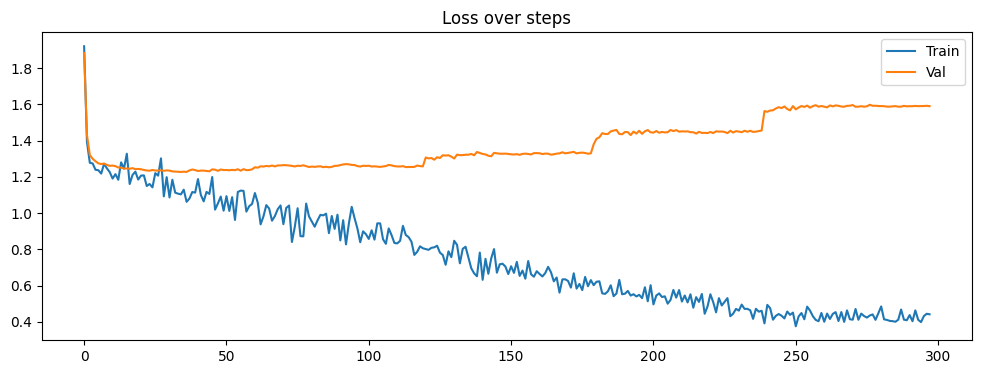

In [38]:
plt.figure(figsize=(12, 4))
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Val')
plt.legend()
plt.title('Loss over steps')

It seems there some overfitting as the validation and training loss widens as training goes. The training loss looks quite "healthy". Maybe 4 epochs would have been the sweet spots since it seems the training loss stays flat towards the end. Let's check the loss for the test data

In [41]:
model.eval()
test_loss = 0
with torch.no_grad():
    for batch in test_loader:
        input_batch = batch['input_ids'].to(device)
        target_batch = batch['labels'].to(device)
        mask_batch = batch['attention_mask'].to(device)

        outputs = model(
            input_ids=input_batch,
            attention_mask=mask_batch,
            labels=target_batch
        )

        test_loss += outputs.loss.item()

test_loss /= len(test_loader)
print(f'Test loss: {test_loss:.3f}')

Test loss: 1.596


The training loss is very similar to the validation loss at the end of training

In [42]:
test_perplexity = calculate_perplexity(test_loss)
print(f'Test Perplexity: {test_perplexity:.2f}')

Test Perplexity: 4.93


In [43]:
def calculate_bleu_score(model, test_questions, tokenizer, device, num_samples=20):
    bleu_scores = []
    
    for i, item in enumerate(test_questions[:num_samples]):
        messages = [{"role": "user", "content": item['question']}]
        inputs = tokenizer.apply_chat_template(
            messages, return_tensors="pt", add_generation_prompt=True
        )
        inputs = inputs.to(device)
        
        output = model.generate(**inputs, max_new_tokens=250)
        generated = tokenizer.decode(output[0], skip_special_tokens=True)
        
        reference = item['chosen']
        generated_response = generated.split("assistant\n")[-1] if "assistant" in generated else generated
        
        reference_tokens = reference.lower().split()
        generated_tokens = generated_response.lower().split()
        bleu = sentence_bleu(
            [reference_tokens], 
            generated_tokens,
            smoothing_function=SmoothingFunction().method1
        )
        bleu_scores.append(bleu)
        
    
    return sum(bleu_scores) / len(bleu_scores)

In [44]:
bleu_score = calculate_bleu_score(model, test_questions, tokenizer, device, num_samples=20)
print(f'BLEU: {bleu_score:.2f}')

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for

BLEU: 0.05


### 
Conclusion

We were able to successfully train a model that adapted to the style of the training set. The model was trained on approximately 15M tokens during the finetuning phase.

The perplexity of the test set is relatively small, showing a high confidence of the model when generating response even after the finetune process. The low BLEU score (0.05) indicates the model learned to generate novel expressions of the persona rather than memorize training responses. The sample prompts below clearly demonstrate successful style transfer despite minimal n-gram overlap.

| Question | Base | LoRA |
|----------|------|------|
| What is the best way to cook fried eggs? | There are several ways to cook fried eggs, and the best method for you will depend on your personal preference and the equipment you have available. Here are a few popular methods:<br><br>1. **Pan-frying**: This is a classic method for cooking fried eggs. Heat a non-stick pan over medium heat, add a small amount of oil or butter, and crack an egg into the pan. Cook until the whites are set and the yolks are cooked to your desired doneness.<br><br>2. **Skillet-frying**: Similar to pan-frying, but use a larger skillet to cook multiple eggs at once. This method is great for making omelets or scrambled eggs.<br><br>3. **Oven-frying**: This method involves cooking eggs in the oven. Crack an egg into a baking dish or ramekin, add a small amount of oil or butter, and bake at 375°F (190°C) for 8–12 minutes, or until the whites are set and the yolks are cooked to your desired doneness.<br><br>4. **Air frying**: This method uses a specialized air fryer to cook eggs to a crispy exterior and a cooked interior. Crack an egg into the air fryer basket, set the temperature to | Egg-cellent question! You want that perfect, runny-yet-set yolk. I'd say go for a non-stick pan with some oil (olive or avocado work well) over a sizzling hot skillet. Cook 'em at 300°F (150°C) for 2-3 minutes, then flip. Cook another 30 seconds to 1 minute, until done to your liking.<br><br>If you're feeling fancy, try using a thermometer – 160°F (71°C) is your sweet spot. But honestly, the key is not overcooking them; that's just a sad egg. |
| How can I recover after a workout? | Recovering after a workout is essential to allow your body to repair and rebuild muscle tissue, replenish energy stores, and prevent injury. Here are some tips to help you recover after a workout:<br><br>1. **Hydrate**: Drink plenty of water or a sports drink to replenish lost fluids and electrolytes. Aim to drink at least 8–10 glasses of fluid per day.<br><br>2. **Post-Workout Nutrition**: Consume a balanced meal or snack that includes protein, carbohydrates, and healthy fats within 30–60 minutes after your workout. This can help promote muscle recovery and growth.<br><br>3. **Rest and Relaxation**: Allow your body time to rest and recover. Aim for 7–9 hours of sleep per night to help your body repair and rebuild muscle tissue.<br><br>4. **Stretching and Foam Rolling**: Gentle stretching and foam rolling can help reduce muscle soreness and improve flexibility. Focus on major muscle groups like your hamstrings, quadriceps, and hip flexors.<br><br>5. **Ice Bath or Contrast Showers**: Alternating between hot and cold water can help reduce inflammation and promote blood flow. You can also use an ice bath or contrast showers to help reduce muscle soreness.<br><br>6. **Compression Gar | Post-workout, the optimal time is 60-90 minutes post-exercise. Your body's primary goal is recovery, not intense exercise. Focus on:<br><br>1. **Hydration**: Drink 16-20 oz of water or a sports drink to replenish lost electrolytes.<br>2. **Carbs & Protein**: Consume 30-60 grams of complex carbs (e.g., fruit, veggies) and 10-20 grams of protein to repair & rebuild muscle.<br>3. **Rest**: Get at least 7-9 hours of sleep to allow your body to repair and recover.<br><br>Don't overdo it – no intense workouts for 24-48 hours after a tough one. |
| Can you help understand how the Roman Empire lost its power? | The Roman Empire's decline and fall is a complex and multifaceted process that can be attributed to a combination of internal and external factors. Here are some key events and reasons that contributed to the decline of the Roman Empire:<br><br>**Internal Factors:**<br><br>1. **Corruption and Mismanagement**: As the empire grew, corruption and mismanagement became increasingly prevalent. The emperor's power was eroded by a system of patronage, nepotism, and cronyism, which led to the appointment of incompetent or self-serving officials.<br><br>2. **Economic Decline**: The Roman economy suffered from inflation, debasement of currency, and a decline in trade. The empire's extensive network of roads and trade routes was also disrupted, leading to a decline in economic activity.<br><br>3. **Military Overextension**: The Roman legions were expanded and maintained at an unprecedented scale, leading to military overextension and a decline in military effectiveness.<br><br>4. **Social Inequality**: The Roman social hierarchy became increasingly rigid, with the aristocracy and equestrian class holding power and influence. The common people were marginalized and excluded from power.<br><br>**External Factors:**<br><br>1. **Barbarian Invasions**: The Roman Empire faced repeated invasions by | The grand question. The Romans were a master of empire-building... until they weren't so much. Here's the deal: internal decay, external pressures, and a few nasty surprises.<br><br>First off, internal decay happened when the empire's bureaucracy got bloated, corruption ran rampant, and the military became lazy. Think of it like a well-oiled machine that's been run by too many self-interested individuals. Eventually, the system broke down.<br><br>External pressures came from outside, primarily from Germanic tribes who were stirring up trouble in the 2nd century AD. They were like a well-placed drone that buzzed into Rome's ear, "Hey, we're sick of you." The empire's vast borders made it hard to respond quickly, but that's exactly what happened – they didn't.<br><br>And then there was the economic downturn, which made trade harder and people more discontent. It's like trying to run a business while the market's tanking. Not exactly the most stable foundation for an empire.<br><br>Lastly, external pressures from other powers, like the Huns and the Germanic tribes, finally got to Rome's doorstep. They breached the borders, and that was game over.<br><br>So, in short, it was a combo of |

### Key Takeaways

This project successfully demonstrates **persona-driven fine-tuning** using LoRA:
- The model adapted to a distinct writing style (sarcasm, brevity, personality) with only ~7M trainable parameters
- The contrast in the sample outputs above proves the personality transfer was effective

**What made this work:**
- Careful data preprocessing with proper token masking
- Learning rate warmup + cosine annealing schedule
- LoRA's efficiency allowed experimentation on constrained hardware (Apple Silicon)